# Final Project

## 1. Scope the Project

Our plan is to use a supervised learning technique to predict which customers are most likely to cancel their subscription using **the past three months of customer data which includes subscription and listening history**.

## 2. Gather Data

Read the following files into Python:
* Customer data: *maven_music_customers.csv*
* Listing history: *maven_music_listening_history.xlsx*

In [1]:
# Read in the customer data
import pandas as pd
import numpy as np

maven_customers = pd.read_csv("../Data/maven_music_customers.csv")


In [2]:
# Read in the listening history
listening_history = pd.read_excel("../Data/maven_music_listening_history.xlsx")
listening_history

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song
...,...,...,...,...,...
500,7579,111282,4,111,Song
501,6588,111286,1,201,Podcast
502,5763,111333,1,110,Song
503,5763,111333,2,108,Song


In [3]:
# Hint: Where might you find listening history data beyond the ID's?


In [4]:
# Read in the audio data
audio_data = pd.read_excel("../Data/maven_music_listening_history.xlsx", sheet_name=1)
audio_data

,ID,Name,Genre,Popularity
0,Song-101,Dance All Night,Pop,1
1,Song-102,Unbreakable Beat,Pop,2
2,Song-103,Sunset Boulevard,Pop Music,5
3,Song-104,Glowing Hearts,Pop Music,10
4,Song-105,Pop Rocks,Pop Music,52
5,Song-106,My Old Dog and My True Love,Country,23
6,Song-107,Dirt Road Romance,Country,30
7,Song-108,Chase the Dream,Hip Hop,4
8,Song-109,Rise Above,Hip Hop,9
9,Song-110,Boss Moves,Hip Hop,28


In [5]:
# Read in the session data
session_data = pd.read_excel("../Data/maven_music_listening_history.xlsx", sheet_name=2)
session_data

,Session ID,Session Log In Time
0,100520,2023-03-13 18:29:00
1,100522,2023-03-13 22:15:00
2,100525,2023-03-14 10:01:00
3,100527,2023-03-13 14:14:00
4,100538,2023-03-21 12:23:00
...,...,...
85,111263,2023-05-20 15:17:30
86,111273,2023-05-20 16:01:00
87,111282,2023-05-23 23:51:00
88,111286,2023-05-27 02:15:00


## 3. Clean Data

### a. Convert Data Types

Check the data types of the data in the tables and convert to numeric and datetime values as necessary.

In [6]:
# Check the data types
maven_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Customer ID        30 non-null     int64 
 1   Customer Name      30 non-null     object
 2   Email              30 non-null     object
 3   Member Since       30 non-null     object
 4   Subscription Plan  25 non-null     object
 5   Subscription Rate  30 non-null     object
 6   Discount?          7 non-null      object
 7   Cancellation Date  13 non-null     object
dtypes: int64(1), object(7)
memory usage: 2.0+ KB


In [7]:
listening_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Customer ID  505 non-null    int64 
 1   Session ID   505 non-null    int64 
 2   Audio Order  505 non-null    int64 
 3   Audio ID     505 non-null    int64 
 4   Audio Type   505 non-null    object
dtypes: int64(4), object(1)
memory usage: 19.9+ KB


In [8]:
audio_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          17 non-null     object
 1   Name        17 non-null     object
 2   Genre       17 non-null     object
 3   Popularity  17 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 676.0+ bytes


In [9]:
session_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Session ID           90 non-null     int64         
 1   Session Log In Time  90 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 1.5 KB


In [10]:
# Convert objects to numeric and datetime fields
maven_customers["Member Since"] = pd.to_datetime(maven_customers["Member Since"])
maven_customers["Cancellation Date"] = pd.to_datetime(maven_customers["Cancellation Date"])
maven_customers["Subscription Rate"] = pd.to_numeric(maven_customers["Subscription Rate"].str.replace("$", ""))

C:\Users\alex\AppData\Local\Temp\ipykernel_14192\997462458.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  maven_customers["Member Since"] = pd.to_datetime(maven_customers["Member Since"])
C:\Users\alex\AppData\Local\Temp\ipykernel_14192\997462458.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  maven_customers["Cancellation Date"] = pd.to_datetime(maven_customers["Cancellation Date"])


In [11]:
maven_customers.head(2)

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,NaN,NaT
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,NaN,2.99,NaN,NaT


### b. Resolve Data Issues

Check for missing data, inconsistent text and typos, duplicate data and outliers.

#### i. Missing Data

In [12]:
maven_customers.shape

(30, 8)

In [13]:
# Look for NaN values in the data
maven_customers.isna().sum()


Customer ID           0
Customer Name         0
Email                 0
Member Since          0
Subscription Plan     5
Subscription Rate     0
Discount?            23
Cancellation Date    17
dtype: int64

In [14]:
maven_customers["Discount?"].value_counts(dropna=True)

Discount?
Yes    7
Name: count, dtype: int64

In [15]:
maven_customers["Discount?"] = np.where(maven_customers["Discount?"] == "Yes", 1, 0)
maven_customers

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,NaN,2.99,0,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,NaN,2.99,0,2023-06-01
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,NaN,2.99,0,NaT
5,5404,Jazz Saxton,Email: jazzy.sax@email.com,2023-03-20,NaN,2.99,0,2023-06-03
6,5581,Reed Sharp,Email: sharp.tunes@email.com,2023-03-21,Premium (No Ads),9.99,0,NaT
7,5759,Carol Kingbird,Email: songbird.carol@email.com,2023-03-22,Premium (No Ads),9.99,0,2023-06-02
8,5761,Sonata Nash,Email: musical.sonata@email.com,2023-03-28,Premium (No Ads),9.99,0,NaT
9,5763,Jazz Coleman,Email: coleman.jazzmaster@email.com,2023-03-28,Basic (Ads),2.99,0,NaT


In [16]:
maven_customers[maven_customers.isna().any(axis=1)]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,NaN,2.99,0,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,NaN,2.99,0,2023-06-01
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,NaN,2.99,0,NaT
5,5404,Jazz Saxton,Email: jazzy.sax@email.com,2023-03-20,NaN,2.99,0,2023-06-03
6,5581,Reed Sharp,Email: sharp.tunes@email.com,2023-03-21,Premium (No Ads),9.99,0,NaT
8,5761,Sonata Nash,Email: musical.sonata@email.com,2023-03-28,Premium (No Ads),9.99,0,NaT
9,5763,Jazz Coleman,Email: coleman.jazzmaster@email.com,2023-03-28,Basic (Ads),2.99,0,NaT
10,5826,Chord Hayes,Email: harmonic.chord@email.com,2023-03-28,Basic (Ads),2.99,0,NaT


In [17]:
maven_customers[maven_customers["Subscription Plan"].isna()]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,NaN,2.99,0,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,NaN,2.99,0,2023-06-01
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,NaN,2.99,0,NaT
5,5404,Jazz Saxton,Email: jazzy.sax@email.com,2023-03-20,NaN,2.99,0,2023-06-03
11,5827,Rhythm Franklin,Email: rhythmic.franklin@email.edu,2023-03-28,NaN,2.99,0,NaT


In [18]:
maven_customers["Subscription Plan"] = maven_customers["Subscription Plan"].fillna("Basic (Ads)")
maven_customers 

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT
5,5404,Jazz Saxton,Email: jazzy.sax@email.com,2023-03-20,Basic (Ads),2.99,0,2023-06-03
6,5581,Reed Sharp,Email: sharp.tunes@email.com,2023-03-21,Premium (No Ads),9.99,0,NaT
7,5759,Carol Kingbird,Email: songbird.carol@email.com,2023-03-22,Premium (No Ads),9.99,0,2023-06-02
8,5761,Sonata Nash,Email: musical.sonata@email.com,2023-03-28,Premium (No Ads),9.99,0,NaT
9,5763,Jazz Coleman,Email: coleman.jazzmaster@email.com,2023-03-28,Basic (Ads),2.99,0,NaT


In [19]:
listening_history.isna().sum()

Customer ID    0
Session ID     0
Audio Order    0
Audio ID       0
Audio Type     0
dtype: int64

In [20]:
audio_data.isna().sum()

ID            0
Name          0
Genre         0
Popularity    0
dtype: int64

In [21]:
session_data.isna().sum()

Session ID             0
Session Log In Time    0
dtype: int64

#### ii. Inconsistent Text & Typos

In [22]:
# Look for inconsistent text & typos
maven_customers.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT


In [23]:
maven_customers["Email"].value_counts()

Email
Email: harmonious.vibes@email.com      1
Email: melodious.aria@email.edu        1
Email: rhythmical.lyric@email.com      1
Email: groovy.rock@email.com           1
Email: beats.by.rhythm@email.edu       1
Email: jazzy.sax@email.com             1
Email: sharp.tunes@email.com           1
Email: songbird.carol@email.com        1
Email: musical.sonata@email.com        1
Email: coleman.jazzmaster@email.com    1
Email: harmonic.chord@email.com        1
Email: rhythmic.franklin@email.edu     1
Email: campbell.chordify@email.com     1
Email: rhythmic.benny@email.com        1
Email: park.of.melodies@email.com      1
Email: rhodes.symphony@email.com       1
Email: beats.by.beatrice@email.com     1
Email: bass.master.bobby@email.edu     1
Email: lyrical.saunders@email.edu      1
Email: bass.harmony@email.com          1
Email: flat.tunes@email.edu            1
Email: kiki.keys.piano@email.com       1
Email: groovy.greta@email.com          1
Email: heartfelt.harmony@email.com     1
Email: wal

In [24]:
listening_history.head()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song


In [25]:
listening_history.describe()

,Customer ID,Session ID,Audio Order,Audio ID
count,505.000000,505.000000,505.000000,505.000000
mean,6112.247525,105225.554455,4.138614,112.063366
std,832.861221,3625.879577,2.669008,24.670285
min,5001.000000,100520.000000,1.000000,101.000000
25%,5267.000000,101925.000000,2.000000,103.000000
50%,6029.000000,105116.000000,4.000000,105.000000
75%,6822.000000,109654.000000,6.000000,109.000000
max,7583.000000,111333.000000,15.000000,205.000000


In [26]:
session_data.describe()

,Session ID,Session Log In Time
count,90.000000,90
mean,105619.788889,2023-04-27 08:18:34.000000512
min,100520.000000,2023-03-13 14:14:00
25%,102149.000000,2023-04-05 21:21:30
50%,105390.500000,2023-05-03 20:03:00
75%,109658.250000,2023-05-18 22:17:30
max,111333.000000,2023-05-31 06:03:00
std,3616.208569,NaN


In [27]:
audio_data.Genre.value_counts()

Genre
Pop Music     3
Comedy        3
Hip Hop       3
Country       2
Pop           2
Jazz          2
True Crime    2
Name: count, dtype: int64

In [28]:
audio_data.Genre = np.where(audio_data.Genre == "Pop Music", "Pop", audio_data.Genre)

In [29]:
maven_customers[maven_customers["Subscription Rate"] >= 99.99]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
15,6229,Symphony Rhodes,Email: rhodes.symphony@email.com,2023-04-06,Premium (No Ads),99.99,0,2023-06-02


In [30]:
maven_customers[maven_customers["Subscription Rate"] >= 9.99]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
6,5581,Reed Sharp,Email: sharp.tunes@email.com,2023-03-21,Premium (No Ads),9.99,0,NaT
7,5759,Carol Kingbird,Email: songbird.carol@email.com,2023-03-22,Premium (No Ads),9.99,0,2023-06-02
8,5761,Sonata Nash,Email: musical.sonata@email.com,2023-03-28,Premium (No Ads),9.99,0,NaT
12,6029,Chord Campbell,Email: campbell.chordify@email.com,2023-03-29,Premium (No Ads),9.99,0,2023-06-02
14,6163,Melody Parks,Email: park.of.melodies@email.com,2023-04-05,Premium (No Ads),9.99,0,NaT
15,6229,Symphony Rhodes,Email: rhodes.symphony@email.com,2023-04-06,Premium (No Ads),99.99,0,2023-06-02


In [31]:
maven_customers["Subscription Rate"] = np.where(maven_customers["Subscription Rate"] == 99.99, 9.99, maven_customers["Subscription Rate"])


In [32]:
maven_customers["Discount?"].value_counts()

Discount?
0    23
1     7
Name: count, dtype: int64

In [33]:
maven_customers["Subscription Rate"].value_counts()

Subscription Rate
2.99    17
7.99     7
9.99     6
Name: count, dtype: int64

In [34]:
maven_customers.head(8)

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT
5,5404,Jazz Saxton,Email: jazzy.sax@email.com,2023-03-20,Basic (Ads),2.99,0,2023-06-03
6,5581,Reed Sharp,Email: sharp.tunes@email.com,2023-03-21,Premium (No Ads),9.99,0,NaT
7,5759,Carol Kingbird,Email: songbird.carol@email.com,2023-03-22,Premium (No Ads),9.99,0,2023-06-02


#### iii. Duplicate Rows

In [35]:
# Look for duplicate rows
maven_customers[maven_customers.duplicated(keep=False)]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date


In [36]:
listening_history[listening_history.duplicated(keep=False)]

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type


In [37]:
audio_data[audio_data.duplicated(keep=False)]

,ID,Name,Genre,Popularity


In [38]:
session_data[session_data.duplicated(keep=False)]

,Session ID,Session Log In Time


#### iv. Outliers

In [39]:
# Look for outliers
maven_customers.describe()

,Customer ID,Member Since,Subscription Rate,Discount?,Cancellation Date
count,30.000000,30,30.000000,30.000000,13
mean,6276.333333,2023-04-10 06:24:00,5.556667,0.233333,2023-06-01 16:36:55.384615424
min,5001.000000,2023-03-13 00:00:00,2.990000,0.000000,2023-06-01 00:00:00
25%,5759.500000,2023-03-23 12:00:00,2.990000,0.000000,2023-06-01 00:00:00
50%,6196.000000,2023-04-05 12:00:00,2.990000,0.000000,2023-06-02 00:00:00
75%,6823.500000,2023-05-01 00:00:00,7.990000,0.000000,2023-06-02 00:00:00
max,7583.000000,2023-05-16 00:00:00,9.990000,1.000000,2023-06-03 00:00:00
std,814.255587,NaN,3.058998,0.430183,NaN


In [40]:
listening_history.describe()

,Customer ID,Session ID,Audio Order,Audio ID
count,505.000000,505.000000,505.000000,505.000000
mean,6112.247525,105225.554455,4.138614,112.063366
std,832.861221,3625.879577,2.669008,24.670285
min,5001.000000,100520.000000,1.000000,101.000000
25%,5267.000000,101925.000000,2.000000,103.000000
50%,6029.000000,105116.000000,4.000000,105.000000
75%,6822.000000,109654.000000,6.000000,109.000000
max,7583.000000,111333.000000,15.000000,205.000000


In [41]:
listening_history[listening_history["Audio Order"] >= 12]

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
20,5001,100522,12,109,Song
80,6584,100789,12,112,Song
81,6584,100789,13,101,Song
82,6584,100789,14,102,Song
83,6584,100789,15,103,Song
145,6584,102129,12,112,Song
277,6586,105356,12,103,Song


In [42]:
audio_data.describe()

,Popularity
count,17.000000
mean,21.058824
std,23.381271
min,1.000000
25%,4.000000
50%,10.000000
75%,28.000000
max,80.000000


In [43]:
audio_data[audio_data["Popularity"] > 28]

,ID,Name,Genre,Popularity
4,Song-105,Pop Rocks,Pop,52
6,Song-107,Dirt Road Romance,Country,30
10,Song-111,Moonlit Serenade,Jazz,63
11,Song-112,Midnight Blues,Jazz,80


In [44]:
session_data.describe()

,Session ID,Session Log In Time
count,90.000000,90
mean,105619.788889,2023-04-27 08:18:34.000000512
min,100520.000000,2023-03-13 14:14:00
25%,102149.000000,2023-04-05 21:21:30
50%,105390.500000,2023-05-03 20:03:00
75%,109658.250000,2023-05-18 22:17:30
max,111333.000000,2023-05-31 06:03:00
std,3616.208569,NaN


### c. Create New Columns

Create two new columns that will be useful for EDA and modeling:
* Cancelled: whether a customer cancelled or not
* Email: Remove the "Email:" from the email addresses

In [45]:
# Create a 'Cancelled' column
maven_customers.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT


In [46]:
maven_customers["Cancelled"] = np.where(maven_customers["Cancellation Date"].notna(), 1, 0)

In [47]:
# Create an updated 'Email' column without the Email: portion
maven_customers.Email = maven_customers.Email.str.strip("Email:").str.replace(" ", "")

## 4. EDA

Try to better understand the customers who cancelled:
* How long were they members before they cancelled?
* What percentage of customers who cancelled had a discount vs customers who didn't cancel?

In [48]:
# How long were customers members before they cancelled?
maven_customers.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled
0,5001,Harmony Greene,harmonious.vibes@email.co,2023-03-13,Basic (Ads),2.99,0,NaT,0
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT,0
2,5004,Lyric Bell,rhythmical.lyric@email.co,2023-03-13,Basic (Ads),2.99,0,2023-06-01,1
3,5267,Rock Bassett,groovy.rock@email.co,2023-03-20,Basic (Ads),2.99,0,NaT,0
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT,0


In [49]:
maven_customers[maven_customers["Cancelled"] == 1].head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled
2,5004,Lyric Bell,rhythmical.lyric@email.co,2023-03-13,Basic (Ads),2.99,0,2023-06-01,1
5,5404,Jazz Saxton,jazzy.sax@email.co,2023-03-20,Basic (Ads),2.99,0,2023-06-03,1
7,5759,Carol Kingbird,songbird.carol@email.co,2023-03-22,Premium (No Ads),9.99,0,2023-06-02,1
12,6029,Chord Campbell,campbell.chordify@email.co,2023-03-29,Premium (No Ads),9.99,0,2023-06-02,1
13,6092,Benny Beat,rhythmic.benny@email.co,2023-04-01,Basic (Ads),2.99,0,2023-06-01,1


In [50]:
(maven_customers["Cancellation Date"] - maven_customers["Member Since"]).mean()

Timedelta('46 days 07:23:04.615384615')

In [51]:
# Cancellation rate for those who had a discount
yes_discount = maven_customers[maven_customers["Discount?"] == 1]
yes_discount

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled
21,6822,Kiki Keys,kiki.keys.piano@email.co,2023-05-01,Premium (No Ads),7.99,1,NaT,0
22,6824,Greta Groove,groovy.greta@email.co,2023-05-01,Premium (No Ads),7.99,1,2023-06-02,1
23,7087,Harmony Heart,heartfelt.harmony@email.co,2023-05-01,Premium (No Ads),7.99,1,2023-06-02,1
25,7224,Melody Fitzgerald,fitzgerald.melody@email.co,2023-05-08,Premium (No Ads),7.99,1,2023-06-01,1
26,7401,Reed Murphy,murphy.reed.music@email.co,2023-05-08,Premium (No Ads),7.99,1,2023-06-01,1
28,7581,Lyric Keys,keysoflyric@email.co,2023-05-16,Premium (No Ads),7.99,1,2023-06-03,1
29,7583,Melody Singer,melodic.singer@email.co,2023-05-16,Premium (No Ads),7.99,1,2023-06-01,1


In [52]:
yes_discount["Cancelled"].sum() / yes_discount["Cancelled"].count()

np.float64(0.8571428571428571)

In [53]:
# Cancellation rate for those who did not have a discount
no_discount = maven_customers[maven_customers["Discount?"] == 0]
no_discount

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled
0,5001,Harmony Greene,harmonious.vibes@email.co,2023-03-13,Basic (Ads),2.99,0,NaT,0
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT,0
2,5004,Lyric Bell,rhythmical.lyric@email.co,2023-03-13,Basic (Ads),2.99,0,2023-06-01,1
3,5267,Rock Bassett,groovy.rock@email.co,2023-03-20,Basic (Ads),2.99,0,NaT,0
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT,0
5,5404,Jazz Saxton,jazzy.sax@email.co,2023-03-20,Basic (Ads),2.99,0,2023-06-03,1
6,5581,Reed Sharp,sharp.tunes@email.co,2023-03-21,Premium (No Ads),9.99,0,NaT,0
7,5759,Carol Kingbird,songbird.carol@email.co,2023-03-22,Premium (No Ads),9.99,0,2023-06-02,1
8,5761,Sonata Nash,musical.sonata@email.co,2023-03-28,Premium (No Ads),9.99,0,NaT,0
9,5763,Jazz Coleman,coleman.jazzmaster@email.co,2023-03-28,Basic (Ads),2.99,0,NaT,0


In [54]:
 no_discount["Cancelled"].sum() / no_discount["Cancelled"].count()

np.float64(0.30434782608695654)

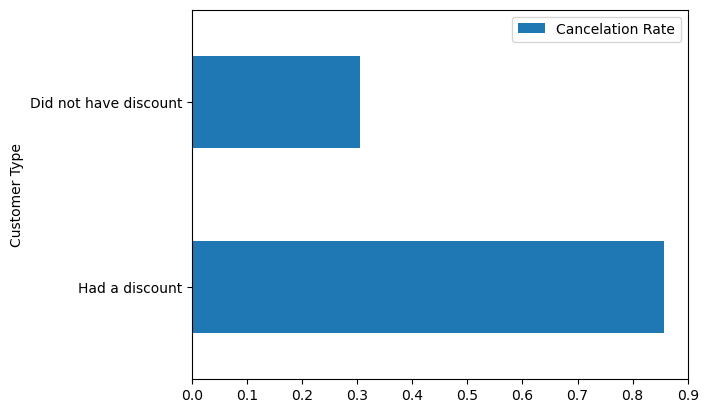

In [55]:
# Visualize the cancellation rate for those with a discount vs those without a discount
pd.DataFrame([["Had a discount", 0.8571428571428571 ], ["Did not have discount", 0.30434782608695654]], 
             columns=["Customer Type", "Cancelation Rate"]).plot.barh(x="Customer Type", y="Cancelation Rate", );
             

Better understand the customers' listening histories:
* Join together the listening history and audio tables
* How many listening sessions did each customer have in the past 3 months?
* What were the most popular genres that customers listened to?

In [56]:
# Split the ID in the audio data so the column can be joined with other tables
maven_customers.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled
0,5001,Harmony Greene,harmonious.vibes@email.co,2023-03-13,Basic (Ads),2.99,0,NaT,0
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT,0
2,5004,Lyric Bell,rhythmical.lyric@email.co,2023-03-13,Basic (Ads),2.99,0,2023-06-01,1
3,5267,Rock Bassett,groovy.rock@email.co,2023-03-20,Basic (Ads),2.99,0,NaT,0
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT,0


In [57]:
listening_history.head()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song


In [58]:
session_data.head()

,Session ID,Session Log In Time
0,100520,2023-03-13 18:29:00
1,100522,2023-03-13 22:15:00
2,100525,2023-03-14 10:01:00
3,100527,2023-03-13 14:14:00
4,100538,2023-03-21 12:23:00


In [59]:
audio_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          17 non-null     object
 1   Name        17 non-null     object
 2   Genre       17 non-null     object
 3   Popularity  17 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 676.0+ bytes


In [60]:
audio_data.head()

,ID,Name,Genre,Popularity
0,Song-101,Dance All Night,Pop,1
1,Song-102,Unbreakable Beat,Pop,2
2,Song-103,Sunset Boulevard,Pop,5
3,Song-104,Glowing Hearts,Pop,10
4,Song-105,Pop Rocks,Pop,52


In [61]:
clean_data = pd.DataFrame(audio_data["ID"].str.split("-").to_list()).rename(columns={0:"Type", 1:"Audio ID"})
clean_data.head()

,Type,Audio ID
0,Song,101
1,Song,102
2,Song,103
3,Song,104
4,Song,105


In [62]:
listening_history.head()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song


In [63]:
all_data =  pd.concat([clean_data, audio_data], axis=1)
all_data.head()

,Type,Audio ID,ID,Name,Genre,Popularity
0,Song,101,Song-101,Dance All Night,Pop,1
1,Song,102,Song-102,Unbreakable Beat,Pop,2
2,Song,103,Song-103,Sunset Boulevard,Pop,5
3,Song,104,Song-104,Glowing Hearts,Pop,10
4,Song,105,Song-105,Pop Rocks,Pop,52


In [64]:
all_data["Audio ID"] = pd.to_numeric(all_data["Audio ID"])

In [65]:
df = listening_history.merge(all_data, how="left", on="Audio ID")
df

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type,Type,ID,Name,Genre,Popularity
0,5001,100520,1,101,Song,Song,Song-101,Dance All Night,Pop,1
1,5001,100520,2,102,Song,Song,Song-102,Unbreakable Beat,Pop,2
2,5001,100520,3,103,Song,Song,Song-103,Sunset Boulevard,Pop,5
3,5001,100520,4,104,Song,Song,Song-104,Glowing Hearts,Pop,10
4,5001,100520,5,105,Song,Song,Song-105,Pop Rocks,Pop,52
...,...,...,...,...,...,...,...,...,...,...
500,7579,111282,4,111,Song,Song,Song-111,Moonlit Serenade,Jazz,63
501,6588,111286,1,201,Podcast,Podcast,Podcast-201,Jokes on Jokes,Comedy,2
502,5763,111333,1,110,Song,Song,Song-110,Boss Moves,Hip Hop,28
503,5763,111333,2,108,Song,Song,Song-108,Chase the Dream,Hip Hop,4


In [66]:
# Hint: Check the data type of Audio ID in the audio table
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Customer ID  505 non-null    int64 
 1   Session ID   505 non-null    int64 
 2   Audio Order  505 non-null    int64 
 3   Audio ID     505 non-null    int64 
 4   Audio Type   505 non-null    object
 5   Type         505 non-null    object
 6   ID           505 non-null    object
 7   Name         505 non-null    object
 8   Genre        505 non-null    object
 9   Popularity   505 non-null    int64 
dtypes: int64(5), object(5)
memory usage: 39.6+ KB


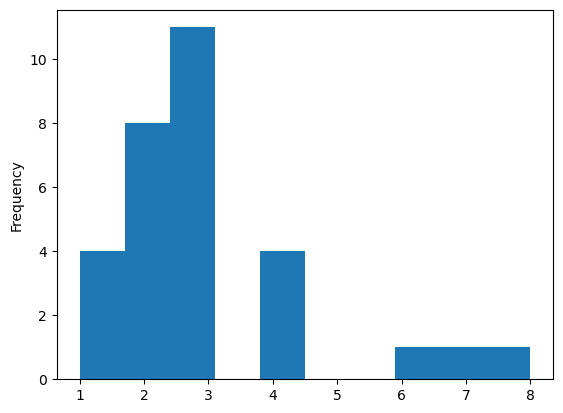

In [67]:
df.groupby("Customer ID")["Session ID"].nunique().plot.hist();

In [68]:
# The most popular genres that customers listened to
df.head()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type,Type,ID,Name,Genre,Popularity
0,5001,100520,1,101,Song,Song,Song-101,Dance All Night,Pop,1
1,5001,100520,2,102,Song,Song,Song-102,Unbreakable Beat,Pop,2
2,5001,100520,3,103,Song,Song,Song-103,Sunset Boulevard,Pop,5
3,5001,100520,4,104,Song,Song,Song-104,Glowing Hearts,Pop,10
4,5001,100520,5,105,Song,Song,Song-105,Pop Rocks,Pop,52


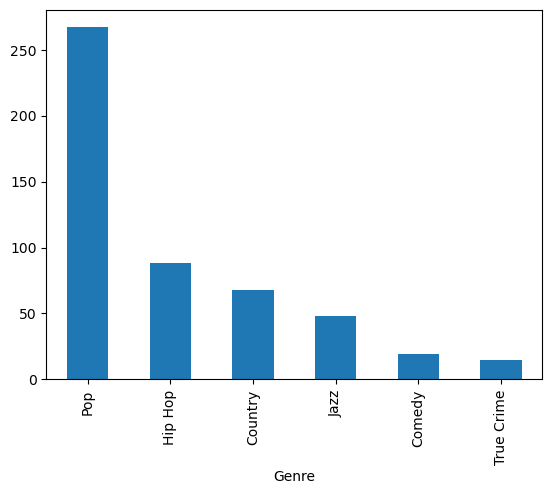

In [69]:
df.Genre.value_counts().plot.bar();

## 5. Prep for Modeling

Create a DataFrame that is ready for modeling with each row representing a customer and the following numeric, non-null columns:
* Customer ID
* Whether a customer cancelled or not
* Whether a customer received a discount or not
* The number of listening sessions
* Percent of listening history consisting of Pop
* Percent of listening history consisting of Podcasts

In [79]:
# Create a dataframe ready for modeling
df.head(2)

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type,Type,ID,Name,Genre,Popularity
0,5001,100520,1,101,Song,Song,Song-101,Dance All Night,Pop,1
1,5001,100520,2,102,Song,Song,Song-102,Unbreakable Beat,Pop,2


In [82]:
modeling_df = maven_customers[["Customer ID", "Cancelled", "Discount?"]]
modeling_df.head()

,Customer ID,Cancelled,Discount?
0,5001,0,0
1,5002,0,0
2,5004,1,0
3,5267,0,0
4,5338,0,0


In [89]:
df.head()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type,Type,ID,Name,Genre,Popularity
0,5001,100520,1,101,Song,Song,Song-101,Dance All Night,Pop,1
1,5001,100520,2,102,Song,Song,Song-102,Unbreakable Beat,Pop,2
2,5001,100520,3,103,Song,Song,Song-103,Sunset Boulevard,Pop,5
3,5001,100520,4,104,Song,Song,Song-104,Glowing Hearts,Pop,10
4,5001,100520,5,105,Song,Song,Song-105,Pop Rocks,Pop,52


In [95]:
# Calculate the number of listening sessions for each customer
df.groupby("Customer ID")["Session ID"].nunique()

Customer ID
5001    8
5002    4
5004    1
5267    7
5338    4
5404    1
5581    3
5759    2
5761    3
5763    6
5826    3
5827    1
6029    2
6092    3
6163    3
6229    2
6406    3
6584    2
6586    2
6588    3
6821    2
6822    3
6824    4
7087    3
7158    3
7224    4
7401    3
7579    2
7581    2
7583    1
Name: Session ID, dtype: int64

In [104]:
listening_sessions = df.groupby("Customer ID")["Session ID"].nunique().rename("Number of Sessions").to_frame().reset_index()
listening_sessions

,Customer ID,Number of Sessions
0,5001,8
1,5002,4
2,5004,1
3,5267,7
4,5338,4
5,5404,1
6,5581,3
7,5759,2
8,5761,3
9,5763,6


In [106]:
model_df = modeling_df.merge(listening_sessions, how="left", on="Customer ID")
model_df

,Customer ID,Cancelled,Discount?,Number of Sessions
0,5001,0,0,8
1,5002,0,0,4
2,5004,1,0,1
3,5267,0,0,7
4,5338,0,0,4
5,5404,1,0,1
6,5581,0,0,3
7,5759,1,0,2
8,5761,0,0,3
9,5763,0,0,6


In [110]:
df.head()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type,Type,ID,Name,Genre,Popularity
0,5001,100520,1,101,Song,Song,Song-101,Dance All Night,Pop,1
1,5001,100520,2,102,Song,Song,Song-102,Unbreakable Beat,Pop,2
2,5001,100520,3,103,Song,Song,Song-103,Sunset Boulevard,Pop,5
3,5001,100520,4,104,Song,Song,Song-104,Glowing Hearts,Pop,10
4,5001,100520,5,105,Song,Song,Song-105,Pop Rocks,Pop,52


In [114]:
pd.get_dummies(df.Genre, dtype="int")

,Comedy,Country,Hip Hop,Jazz,Pop,True Crime
0,0,0,0,0,1,0
1,0,0,0,0,1,0
2,0,0,0,0,1,0
3,0,0,0,0,1,0
4,0,0,0,0,1,0
...,...,...,...,...,...,...
500,0,0,0,1,0,0
501,1,0,0,0,0,0
502,0,0,1,0,0,0
503,0,0,1,0,0,0


In [156]:
model_df_2 = pd.concat([df["Customer ID"], pd.get_dummies(df.Genre, dtype="int")], axis=1)
model_df_2

,Customer ID,Comedy,Country,Hip Hop,Jazz,Pop,True Crime
0,5001,0,0,0,0,1,0
1,5001,0,0,0,0,1,0
2,5001,0,0,0,0,1,0
3,5001,0,0,0,0,1,0
4,5001,0,0,0,0,1,0
...,...,...,...,...,...,...,...
500,7579,0,0,0,1,0,0
501,6588,1,0,0,0,0,0
502,5763,0,0,1,0,0,0
503,5763,0,0,1,0,0,0


In [157]:
model_df_2 = model_df_2.groupby("Customer ID")[["Comedy", "Country", "Hip Hop" ,"Jazz" ,"Pop", "True Crime"]].sum().reset_index()
model_df_2.head()

,Customer ID,Comedy,Country,Hip Hop,Jazz,Pop,True Crime
0,5001,0,0,26,0,34,0
1,5002,0,22,0,0,0,0
2,5004,0,0,0,0,9,0
3,5267,0,0,22,0,23,0
4,5338,0,18,0,0,0,0


In [136]:
total_audio = df.groupby("Customer ID")["Audio ID"].count().rename("Total Audio").to_frame().reset_index()
total_audio.head()

,Customer ID,Total Audio
0,5001,60
1,5002,22
2,5004,9
3,5267,45
4,5338,18


In [158]:
model_df_2 = model_df_2.merge(total_audio, how="left", on="Customer ID")

In [160]:
model_df_2.head()

,Customer ID,Comedy,Country,Hip Hop,Jazz,Pop,True Crime,Total Audio
0,5001,0,0,26,0,34,0,60
1,5002,0,22,0,0,0,0,22
2,5004,0,0,0,0,9,0,9
3,5267,0,0,22,0,23,0,45
4,5338,0,18,0,0,0,0,18


In [144]:
new_df = new_df[["Customer ID", "Comedy", "Country", "Hip Hop", "Jazz", "Pop", "True Crime", "Total Audio"]]
new_df.head()

,Customer ID,Comedy,Country,Hip Hop,Jazz,Pop,True Crime,Total Audio
0,5001,0,0,26,0,34,0,60
1,5002,0,22,0,0,0,0,22
2,5004,0,0,0,0,9,0,9
3,5267,0,0,22,0,23,0,45
4,5338,0,18,0,0,0,0,18


In [161]:
# Percent pop
model_df_2["Percent pop"] = (model_df_2["Pop"] / model_df_2["Total Audio"] * 100).round(2)
model_df_2.head()

,Customer ID,Comedy,Country,Hip Hop,Jazz,Pop,True Crime,Total Audio,Percent pop
0,5001,0,0,26,0,34,0,60,56.67
1,5002,0,22,0,0,0,0,22,0.00
2,5004,0,0,0,0,9,0,9,100.00
3,5267,0,0,22,0,23,0,45,51.11
4,5338,0,18,0,0,0,0,18,0.00


In [162]:
# Percent podcasts
model_df_2["Percent podcasts"] = (model_df_2["Comedy"] + model_df_2["True Crime"] / model_df_2["Total Audio"] * 100).round(2)
model_df_2

,Customer ID,Comedy,Country,Hip Hop,Jazz,Pop,True Crime,Total Audio,Percent pop,Percent podcasts
0,5001,0,0,26,0,34,0,60,56.67,0.00
1,5002,0,22,0,0,0,0,22,0.00,0.00
2,5004,0,0,0,0,9,0,9,100.00,0.00
3,5267,0,0,22,0,23,0,45,51.11,0.00
4,5338,0,18,0,0,0,0,18,0.00,0.00
5,5404,0,0,0,0,8,0,8,100.00,0.00
6,5581,0,0,0,0,0,5,5,0.00,100.00
7,5759,0,0,0,0,15,0,15,100.00,0.00
8,5761,0,0,0,0,0,5,5,0.00,100.00
9,5763,0,0,11,0,20,0,31,64.52,0.00


In [169]:
final_model_df = model_df.merge(model_df_2[["Customer ID", "Percent pop", "Percent podcasts"]], how="left", on="Customer ID")
final_model_df

,Customer ID,Cancelled,Discount?,Number of Sessions,Percent pop_x,Percent podcasts_x,Percent pop_y,Percent podcasts_y,Percent pop,Percent podcasts
0,5001,0,0,8,56.67,0.00,56.67,0.00,56.67,0.00
1,5002,0,0,4,0.00,0.00,0.00,0.00,0.00,0.00
2,5004,1,0,1,100.00,0.00,100.00,0.00,100.00,0.00
3,5267,0,0,7,51.11,0.00,51.11,0.00,51.11,0.00
4,5338,0,0,4,0.00,0.00,0.00,0.00,0.00,0.00
5,5404,1,0,1,100.00,0.00,100.00,0.00,100.00,0.00
6,5581,0,0,3,0.00,100.00,0.00,100.00,0.00,100.00
7,5759,1,0,2,100.00,0.00,100.00,0.00,100.00,0.00
8,5761,0,0,3,0.00,100.00,0.00,100.00,0.00,100.00
9,5763,0,0,6,64.52,0.00,64.52,0.00,64.52,0.00


In [172]:
final_model_df = final_model_df[["Customer ID", "Cancelled", "Discount?", "Number of Sessions", "Percent pop", "Percent podcasts"]]
final_model_df

,Customer ID,Cancelled,Discount?,Number of Sessions,Percent pop,Percent podcasts
0,5001,0,0,8,56.67,0.00
1,5002,0,0,4,0.00,0.00
2,5004,1,0,1,100.00,0.00
3,5267,0,0,7,51.11,0.00
4,5338,0,0,4,0.00,0.00
5,5404,1,0,1,100.00,0.00
6,5581,0,0,3,0.00,100.00
7,5759,1,0,2,100.00,0.00
8,5761,0,0,3,0.00,100.00
9,5763,0,0,6,64.52,0.00


Visualize the relationships in the modeling DataFrame using a pair plot:
* What are some of your observations?
* What variables might do a good job predicting customer cancellation?

In [151]:
import seaborn as sns

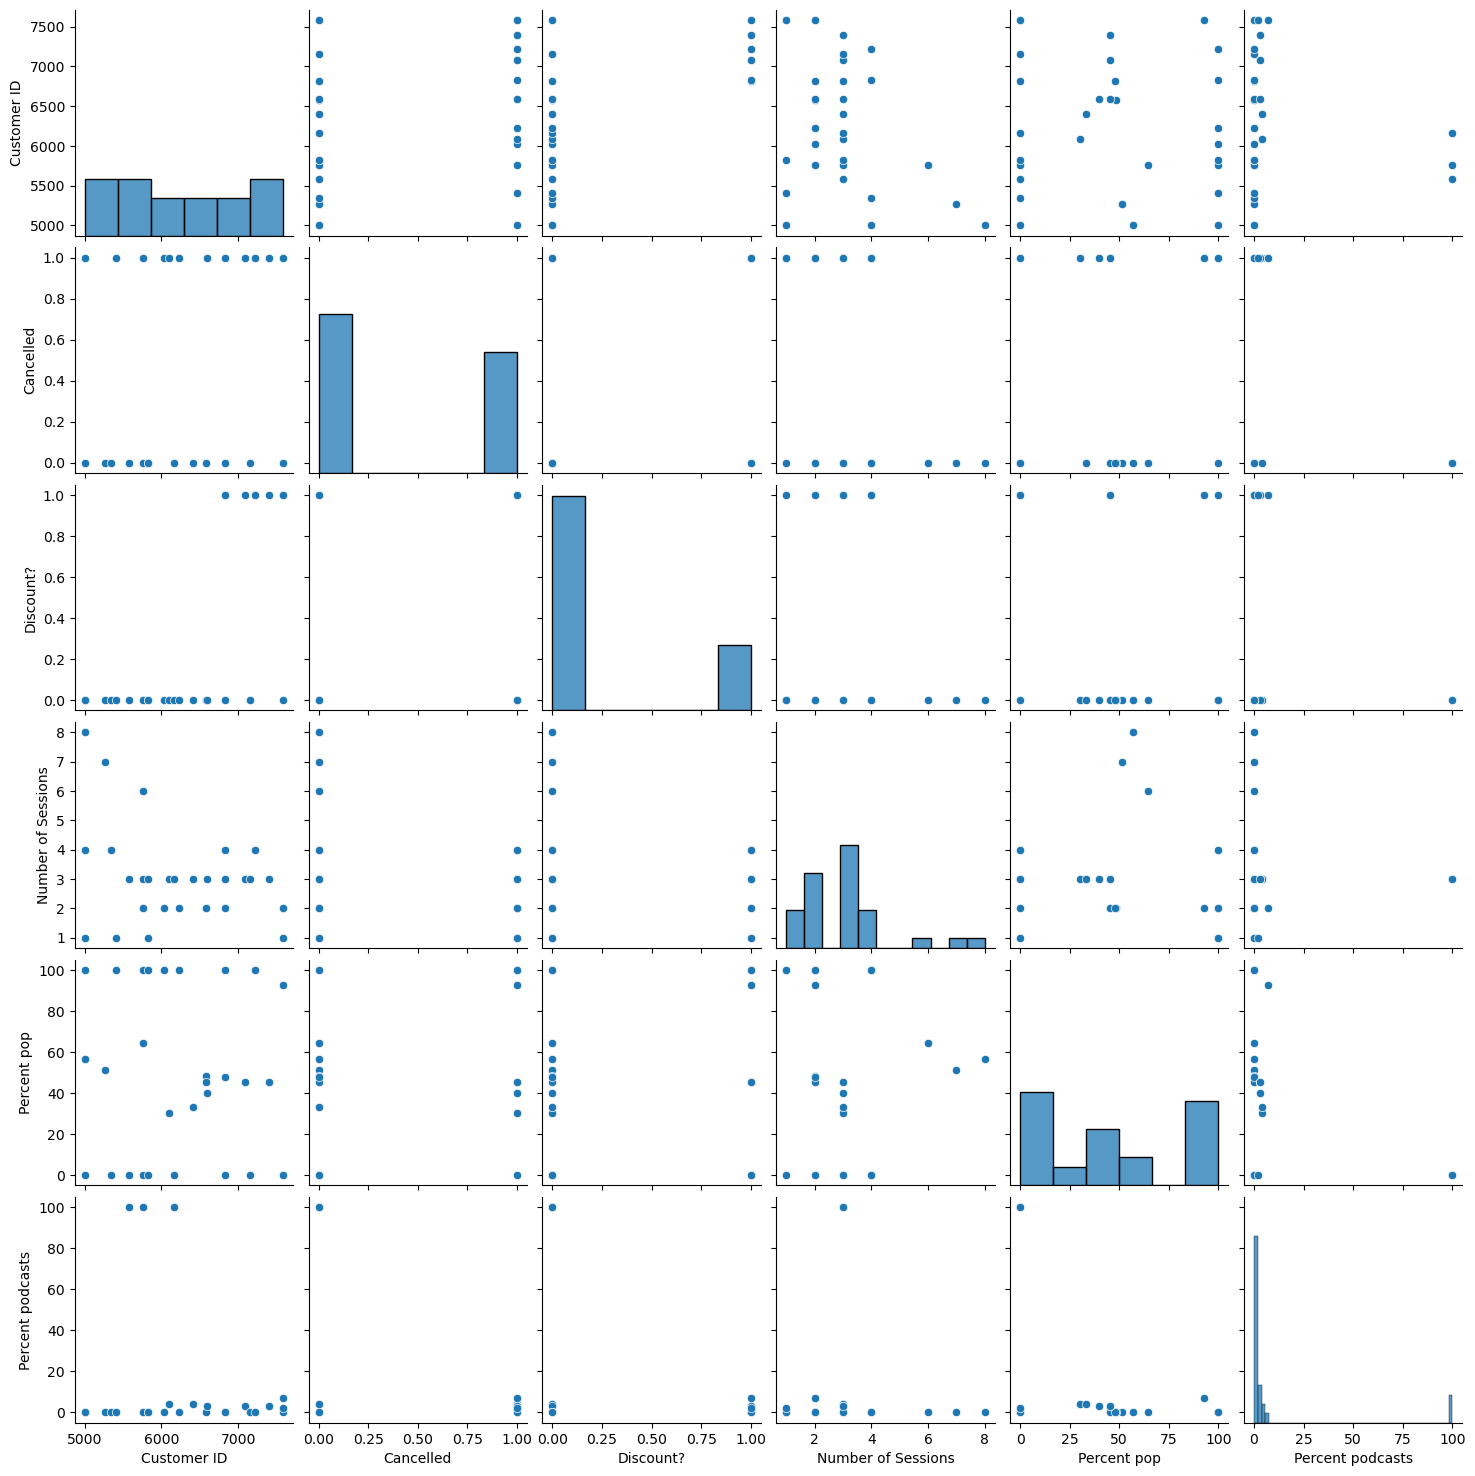

In [173]:
sns.pairplot(final_model_df);

In [174]:
final_model_df.corr()

,Customer ID,Cancelled,Discount?,Number of Sessions,Percent pop,Percent podcasts
Customer ID,1.000000,0.269942,0.648514,-0.337083,-0.076140,-0.159429
Cancelled,0.269942,1.000000,0.471825,-0.333739,0.585620,-0.269409
Discount?,0.648514,0.471825,1.000000,-0.048877,0.112664,-0.161438
Number of Sessions,-0.337083,-0.333739,-0.048877,1.000000,-0.131143,-0.007738
Percent pop,-0.076140,0.585620,0.112664,-0.131143,1.000000,-0.391303
Percent podcasts,-0.159429,-0.269409,-0.161438,-0.007738,-0.391303,1.000000
